# Phase 3 - YOLO26-seg (Rice)

Owner: Nguyen Ho Anh Tuan. This Kaggle notebook trains and evaluates YOLO26-seg for the **Rice** dataset only. It replaces the old combined `train_evaluate_tune.ipynb` for Phase 3 and intentionally does not include Phase 4 tuning.

Official references:
- YOLO26: https://docs.ultralytics.com/models/yolo26
- Instance segmentation: https://docs.ultralytics.com/tasks/segment
- HuggingFace upload: https://huggingface.co/docs/huggingface_hub/en/guides/upload


## 0. Install optional Kaggle dependencies

Local runs should use the repo environment. Kaggle runs can use this cell to install missing runtime packages in the active notebook kernel.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "ultralytics": "ultralytics",
    "huggingface_hub": "huggingface_hub",
    "pycocotools": "pycocotools",
}
missing = [pkg for module, pkg in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Training dependencies already available.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

## 1. Configuration and taxonomy

The PLAN taxonomy is the source of truth. This notebook filters the fixed manifests to one domain so Rice and Coffee can be trained independently on Kaggle.

In [2]:
from __future__ import annotations

import json
import os
import random
import shutil
import time
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image, ImageDraw

SEED = 42
TARGET_DOMAIN = "rice"
assert TARGET_DOMAIN in {"rice", "coffee"}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def find_project_root() -> Path:
    env_root = os.environ.get("PROJECT_ROOT")
    candidates: list[Path] = []
    if env_root:
        candidates.append(Path(env_root))

    # Keep the same first-cell Kaggle style as the old combined notebook, but also
    # scan /kaggle/input because Kaggle dataset slugs differ between accounts.
    candidates.append(Path("/kaggle/input/datasets/tuanho511/ml-vietnam-plant-disease-detection"))
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(sorted(p for p in kaggle_input.glob("**/ml-vietnam-plant-disease-detection") if p.is_dir()))
        candidates.extend(sorted(p for p in kaggle_input.glob("*") if p.is_dir()))

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    for candidate in candidates:
        if (candidate / "data" / "raw").exists() and (candidate / "models" / "class_names.json").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root. Set PROJECT_ROOT explicitly.")


PROJECT_ROOT = find_project_root()
RAW_ROOT = Path(os.environ.get("RAW_DATA_ROOT", PROJECT_ROOT / "data" / "raw"))
MANIFEST_DIR = Path(os.environ.get("MANIFEST_DIR", PROJECT_ROOT / "data" / "processed" / "metadata"))
CLASS_NAMES_PATH = Path(os.environ.get("CLASS_NAMES_PATH", PROJECT_ROOT / "models" / "class_names.json"))

DEFAULT_WORK_DIR = Path(f"/kaggle/working/yolo26_seg_phase3_{TARGET_DOMAIN}") if Path("/kaggle/working").exists() else PROJECT_ROOT / "notebooks" / "models" / "yolo26_seg" / f"_working_{TARGET_DOMAIN}"
WORK_DIR = Path(os.environ.get("WORK_DIR", DEFAULT_WORK_DIR))
DATASET_DIR = WORK_DIR / "dataset"
RUNS_DIR = WORK_DIR / "runs"
ARTIFACTS_DIR = WORK_DIR / "artifacts"
for directory in [DATASET_DIR, RUNS_DIR, ARTIFACTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
YOLO_CONFIG_ROOT = WORK_DIR / "config"
YOLO_CONFIG_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("YOLO_CONFIG_DIR", str(YOLO_CONFIG_ROOT))

PLAN_CLASS_NAMES = [
    "Healthy",
    "BrownSpot",
    "Hispa",
    "LeafBlast",
    "LeafMiner",
    "PowderyMildew",
    "Rust",
    "AlgalLeafSpot",
]
CLASS_NAMES = json.loads(CLASS_NAMES_PATH.read_text(encoding="utf-8")) if CLASS_NAMES_PATH.exists() else PLAN_CLASS_NAMES
if CLASS_NAMES != PLAN_CLASS_NAMES:
    raise ValueError(f"Unexpected class order in {CLASS_NAMES_PATH}: {CLASS_NAMES}")
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}

RICE_CLASSES = {"Healthy", "BrownSpot", "Hispa", "LeafBlast"}
COFFEE_FOLDER_TO_CLASS = {"0": "LeafMiner", "1": "PowderyMildew", "2": "Rust", "3": "AlgalLeafSpot"}
DOMAIN_CLASSES = sorted(RICE_CLASSES if TARGET_DOMAIN == "rice" else set(COFFEE_FOLDER_TO_CLASS.values()), key=CLASS_TO_ID.get)
DEVICE = "0" if torch.cuda.is_available() else "cpu"
print(f"Project root: {PROJECT_ROOT}")
print(f"Target domain: {TARGET_DOMAIN}")
print(f"Classes in this notebook: {DOMAIN_CLASSES}")
print(f"Device: {DEVICE}")
print(f"Work dir: {WORK_DIR}")


Project root: /kaggle/input/datasets/tuanho511/ml-vietnam-plant-disease-detection
Target domain: rice
Classes in this notebook: ['Healthy', 'BrownSpot', 'Hispa', 'LeafBlast']
Device: 0
Work dir: /kaggle/working/yolo26_seg_phase3_rice


## 2. Load fixed manifests and COCO annotations

The train/validation/test manifests remain fixed to avoid leakage. COCO raw annotations are used because polygon coordinates match raw images.

In [3]:
def read_manifest(split: str) -> pd.DataFrame:
    path = MANIFEST_DIR / f"{split}_manifest.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing manifest: {path}")
    df = pd.read_csv(path)
    df["split"] = split
    return df


manifest_df = pd.concat([read_manifest(split) for split in ["train", "val", "test"]], ignore_index=True)
manifest_df = manifest_df[manifest_df["domain"].astype(str).str.lower() == TARGET_DOMAIN].copy()
if manifest_df.empty:
    raise RuntimeError(f"No rows found for domain={TARGET_DOMAIN}")

print(manifest_df.groupby(["split", "label"]).size())


def assert_no_manifest_leakage(df: pd.DataFrame) -> None:
    for field in ["sample_id", "md5"]:
        split_sets = {split: set(part[field].astype(str)) for split, part in df.groupby("split")}
        for left, right in [("train", "val"), ("train", "test"), ("val", "test")]:
            overlap = split_sets.get(left, set()) & split_sets.get(right, set())
            assert not overlap, f"Leakage in {field}: {left}-{right} has {len(overlap)} overlaps"
    print("No manifest leakage by sample_id or md5.")


assert_no_manifest_leakage(manifest_df)


def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing COCO annotation file: {path}")
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


COCO_PATH = RAW_ROOT / f"{TARGET_DOMAIN}_leaf_disease" / "annotations.coco.json"
if TARGET_DOMAIN == "rice":
    COCO_PATH = RAW_ROOT / "rice_leaf_disease" / "annotations.coco.json"
elif TARGET_DOMAIN == "coffee":
    COCO_PATH = RAW_ROOT / "coffee_leaf_disease" / "annotations.coco.json"

coco = load_json(COCO_PATH)
print(f"{TARGET_DOMAIN.title()} COCO images={len(coco['images'])}, annotations={len(coco['annotations'])}")


split  label    
test   BrownSpot      79
       Healthy       221
       Hispa          86
       LeafBlast     117
train  BrownSpot     372
       Healthy      1030
       Hispa         400
       LeafBlast     544
val    BrownSpot      80
       Healthy       221
       Hispa          85
       LeafBlast     116
dtype: int64
No manifest leakage by sample_id or md5.
Rice COCO images=3421, annotations=3720


## 3. Convert COCO polygons to YOLO-seg

Images without valid polygon masks are excluded. Each YOLO label row is `class_id x1 y1 x2 y2 ...` with normalized coordinates in `[0, 1]`.

In [4]:
@dataclass
class CocoIndex:
    images_by_file: dict[str, dict]
    annotations_by_image: dict[int, list[dict]]
    category_to_class: dict[int, str]


def clean_path(value: str) -> str:
    return str(value).replace("\\", "/").strip()


def norm_path(value: str) -> str:
    return clean_path(value).lower()


def has_polygon(segmentation) -> bool:
    return isinstance(segmentation, list) and any(isinstance(poly, list) and len(poly) >= 6 for poly in segmentation)


def build_coco_index(coco_data: dict, domain: str) -> CocoIndex:
    if domain == "rice":
        category_to_class = {
            int(cat["id"]): cat["name"]
            for cat in coco_data.get("categories", [])
            if cat.get("name") in RICE_CLASSES
        }
    elif domain == "coffee":
        category_to_class = {
            int(cat["id"]): COFFEE_FOLDER_TO_CLASS[str(cat["name"])]
            for cat in coco_data.get("categories", [])
            if str(cat.get("name")) in COFFEE_FOLDER_TO_CLASS
        }
    else:
        raise ValueError(domain)

    images_by_file = {norm_path(img["file_name"]): img for img in coco_data.get("images", [])}
    annotations_by_image: dict[int, list[dict]] = defaultdict(list)
    for ann in coco_data.get("annotations", []):
        category_id = int(ann.get("category_id", -1))
        if category_id not in category_to_class:
            continue
        if not has_polygon(ann.get("segmentation")):
            continue
        annotations_by_image[int(ann["image_id"])].append(ann)
    return CocoIndex(images_by_file, dict(annotations_by_image), category_to_class)


COCO_INDEX = build_coco_index(coco, TARGET_DOMAIN)


def coco_file_from_row(row: pd.Series) -> str:
    rel = clean_path(row["relative_path"])
    rel_norm = norm_path(rel)
    marker = "rice_leaf_disease/" if TARGET_DOMAIN == "rice" else "coffee_leaf_disease/"
    marker_idx = rel_norm.find(marker)
    if marker_idx < 0:
        return f"{row['class_folder']}/{row['file_name']}"
    return rel[marker_idx + len(marker):]


def raw_image_path(coco_file_name: str) -> Path:
    raw_domain = "rice_leaf_disease" if TARGET_DOMAIN == "rice" else "coffee_leaf_disease"
    return RAW_ROOT / raw_domain / coco_file_name


def polygon_to_yolo(poly: list[float], width: int, height: int) -> list[float] | None:
    coords = np.asarray(poly, dtype=np.float32).reshape(-1, 2)
    if coords.shape[0] < 3:
        return None
    coords[:, 0] = np.clip(coords[:, 0] / float(width), 0.0, 1.0)
    coords[:, 1] = np.clip(coords[:, 1] / float(height), 0.0, 1.0)
    if np.unique(coords, axis=0).shape[0] < 3:
        return None
    return coords.reshape(-1).tolist()


def reset_dataset_dir() -> None:
    if DATASET_DIR.exists():
        shutil.rmtree(DATASET_DIR)
    for split in ["train", "val", "test"]:
        (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)


def convert_to_yolo(df: pd.DataFrame) -> pd.DataFrame:
    reset_dataset_dir()
    rows: list[dict] = []
    skipped: list[tuple[str, str]] = []

    for _, row in df.iterrows():
        coco_file = coco_file_from_row(row)
        image_info = COCO_INDEX.images_by_file.get(norm_path(coco_file))
        if image_info is None:
            skipped.append((str(row["sample_id"]), "missing_coco_image"))
            continue
        coco_file = clean_path(image_info["file_name"])
        annotations = COCO_INDEX.annotations_by_image.get(int(image_info["id"]), [])
        if not annotations:
            skipped.append((str(row["sample_id"]), "missing_polygon_annotation"))
            continue

        src_image = raw_image_path(coco_file)
        if not src_image.exists():
            skipped.append((str(row["sample_id"]), "missing_raw_image"))
            continue

        split = str(row["split"])
        suffix = src_image.suffix.lower() or ".jpg"
        dst_stem = str(row["sample_id"])
        dst_image = DATASET_DIR / "images" / split / f"{dst_stem}{suffix}"
        dst_label = DATASET_DIR / "labels" / split / f"{dst_stem}.txt"
        shutil.copy2(src_image, dst_image)

        width = int(image_info.get("width") or Image.open(src_image).width)
        height = int(image_info.get("height") or Image.open(src_image).height)
        lines: list[str] = []
        for ann in annotations:
            class_name = COCO_INDEX.category_to_class[int(ann["category_id"])]
            class_id = CLASS_TO_ID[class_name]
            for poly in ann.get("segmentation", []):
                yolo_poly = polygon_to_yolo(poly, width, height)
                if yolo_poly is None:
                    continue
                coord_text = " ".join(f"{v:.6f}" for v in yolo_poly)
                lines.append(f"{class_id} {coord_text}")

        if not lines:
            dst_image.unlink(missing_ok=True)
            skipped.append((str(row["sample_id"]), "no_valid_polygon_after_clip"))
            continue

        dst_label.write_text("\n".join(lines) + "\n", encoding="utf-8")
        rows.append({
            **row.to_dict(),
            "image_path_yolo": str(dst_image),
            "label_path": str(dst_label),
            "num_segments": len(lines),
            "coco_file": coco_file,
        })

    converted = pd.DataFrame(rows)
    if converted.empty:
        raise RuntimeError(f"No converted samples for {TARGET_DOMAIN}. First skipped examples: {skipped[:10]}")

    skipped_df = pd.DataFrame(skipped, columns=["sample_id", "reason"])
    skipped_df.to_csv(ARTIFACTS_DIR / "conversion_skipped.csv", index=False)
    converted.to_csv(ARTIFACTS_DIR / "converted_manifest.csv", index=False)
    return converted


converted_df = convert_to_yolo(manifest_df)
print(converted_df.groupby(["split", "label"])["num_segments"].agg(["count", "sum"]))
print(f"Skipped rows: {len(manifest_df) - len(converted_df)}; details: {ARTIFACTS_DIR / 'conversion_skipped.csv'}")

DATA_YAML = WORK_DIR / f"data_{TARGET_DOMAIN}.yaml"
data_yaml = {
    "path": str(DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {idx: name for idx, name in enumerate(CLASS_NAMES)},
    "nc": len(CLASS_NAMES),
}
DATA_YAML.write_text(yaml.safe_dump(data_yaml, sort_keys=False), encoding="utf-8")
print(DATA_YAML.read_text(encoding="utf-8"))


                 count   sum
split label                 
test  BrownSpot     63   104
      Healthy      206   215
      Hispa         81    88
      LeafBlast     88    99
train BrownSpot    323   445
      Healthy      967  1021
      Hispa        377   566
      LeafBlast    422   583
val   BrownSpot     72    76
      Healthy      208   292
      Hispa         79   122
      LeafBlast     91   104
Skipped rows: 374; details: /kaggle/working/yolo26_seg_phase3_rice/artifacts/conversion_skipped.csv
path: /kaggle/working/yolo26_seg_phase3_rice/dataset
train: images/train
val: images/val
test: images/test
names:
  0: Healthy
  1: BrownSpot
  2: Hispa
  3: LeafBlast
  4: LeafMiner
  5: PowderyMildew
  6: Rust
  7: AlgalLeafSpot
nc: 8



## 4. Conversion validation and ground-truth overlays

Validated 2977 converted images and all YOLO polygons.


,count,sum,mean
split,,,
test,438,506,1.155251
train,2089,2615,1.251795
val,450,594,1.320000


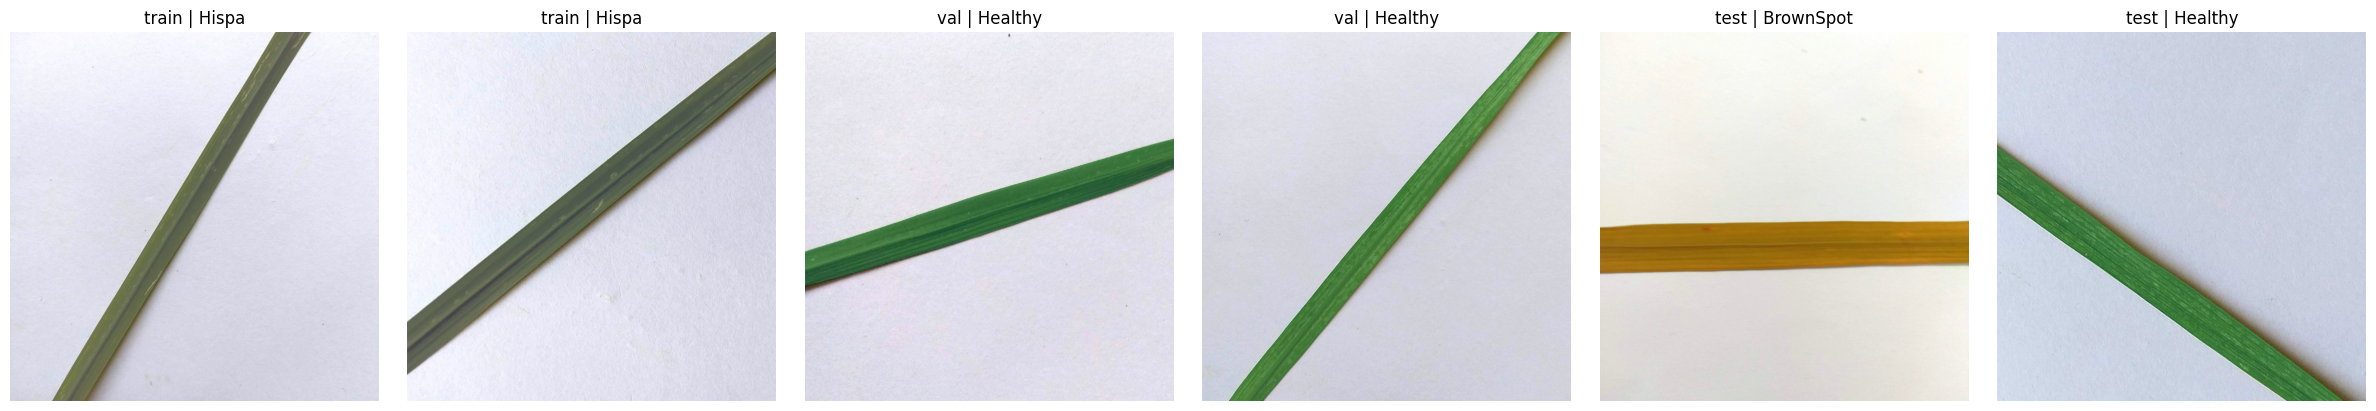

In [5]:
def read_yolo_label(label_path: Path) -> list[tuple[int, np.ndarray]]:
    segments: list[tuple[int, np.ndarray]] = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if not parts:
            continue
        class_id = int(parts[0])
        coords = np.asarray([float(v) for v in parts[1:]], dtype=np.float32).reshape(-1, 2)
        segments.append((class_id, coords))
    return segments


def validate_yolo_labels(df: pd.DataFrame) -> None:
    for _, row in df.iterrows():
        label_path = Path(row["label_path"])
        segments = read_yolo_label(label_path)
        assert segments, f"Empty label file: {label_path}"
        for class_id, coords in segments:
            assert 0 <= class_id < len(CLASS_NAMES), f"Invalid class_id {class_id} in {label_path}"
            assert coords.shape[0] >= 3, f"Polygon has <3 points in {label_path}"
            assert np.all(coords >= 0.0) and np.all(coords <= 1.0), f"Out-of-range polygon in {label_path}"

    split_sets = {split: set(part["md5"].astype(str)) for split, part in df.groupby("split")}
    for left, right in [("train", "val"), ("train", "test"), ("val", "test")]:
        overlap = split_sets.get(left, set()) & split_sets.get(right, set())
        assert not overlap, f"Converted leakage by md5: {left}-{right} has {len(overlap)} overlaps"
    print(f"Validated {len(df)} converted images and all YOLO polygons.")


validate_yolo_labels(converted_df)
display(converted_df.groupby("split")["num_segments"].agg(["count", "sum", "mean"]))

PALETTE = [
    "#1B9E77", "#D95F02", "#7570B3", "#E7298A",
    "#66A61E", "#E6AB02", "#A6761D", "#666666",
]


def overlay_segments(image_path: Path, label_path: Path, alpha: int = 95) -> Image.Image:
    image = Image.open(image_path).convert("RGBA")
    width, height = image.size
    overlay = Image.new("RGBA", image.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    for class_id, coords in read_yolo_label(label_path):
        points = [(float(x) * width, float(y) * height) for x, y in coords]
        rgb = tuple(int(PALETTE[class_id].lstrip("#")[i:i+2], 16) for i in (0, 2, 4))
        draw.polygon(points, outline=rgb + (255,), fill=rgb + (alpha,))
    return Image.alpha_composite(image, overlay).convert("RGB")


sample_df = converted_df.groupby("split", group_keys=False).head(2)
fig, axes = plt.subplots(1, len(sample_df), figsize=(4 * len(sample_df), 4))
if len(sample_df) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, sample_df.iterrows()):
    ax.imshow(overlay_segments(Path(row["image_path_yolo"]), Path(row["label_path"])))
    ax.set_title(f"{row['split']} | {row['label']}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Train Phase 3 baseline

Run the 1-epoch smoke test first, then the full Phase 3 training. Environment overrides: `YOLO_MODEL`, `YOLO_EPOCHS`, `YOLO_BATCH`, `YOLO_IMGSZ`, `RUN_SMOKE_TEST`, `RUN_FULL_TRAINING`.

In [6]:
from ultralytics import YOLO

RUN_SMOKE_TEST = os.environ.get("RUN_SMOKE_TEST", "1") == "1"
RUN_FULL_TRAINING = os.environ.get("RUN_FULL_TRAINING", "1") == "1"

COMMON_ARGS = {
    "data": str(DATA_YAML),
    "imgsz": int(os.environ.get("YOLO_IMGSZ", "640")),
    "batch": int(os.environ.get("YOLO_BATCH", "8")),
    "workers": int(os.environ.get("YOLO_WORKERS", "2")),
    "seed": SEED,
    "deterministic": True,
    "project": str(RUNS_DIR),
    "device": DEVICE,
    "exist_ok": True,
    "plots": True,
    "save": True,
    "val": True,
}

PHASE3_RUN = {
    "name": f"phase3_yolo26n_seg_{TARGET_DOMAIN}",
    "model": os.environ.get("YOLO_MODEL", "yolo26n-seg.pt"),
    "epochs": int(os.environ.get("YOLO_EPOCHS", "50")),
    "optimizer": "auto",
    "patience": int(os.environ.get("YOLO_PATIENCE", "15")),
    "degrees": 15.0,
    "translate": 0.08,
    "scale": 0.20,
    "fliplr": 0.50,
    "flipud": 0.10,
    "hsv_h": 0.015,
    "hsv_s": 0.50,
    "hsv_v": 0.30,
}


def extract_ultralytics_metrics(metrics) -> dict:
    def value(path: str):
        current = metrics
        for part in path.split("."):
            current = getattr(current, part, None)
            if current is None:
                return None
        try:
            return float(current)
        except TypeError:
            return current

    return {
        "mAP50_mask": value("seg.map50"),
        "mAP50_95_mask": value("seg.map"),
        "mAP75_mask": value("seg.map75"),
        "fitness": getattr(metrics, "fitness", None),
    }


def run_train(config: dict) -> dict:
    model = YOLO(config["model"])
    args = {**COMMON_ARGS, **{k: v for k, v in config.items() if k not in {"model"}}}
    print(f"Training {config['name']} with {config['model']}")
    train_result = model.train(**args)
    best_ckpt = Path(train_result.save_dir) / "weights" / "best.pt"
    val_metrics = YOLO(str(best_ckpt)).val(data=str(DATA_YAML), split="test", imgsz=COMMON_ARGS["imgsz"], device=DEVICE, plots=True)
    row = {
        "run": config["name"],
        "model": config["model"],
        "epochs": config["epochs"],
        "imgsz": COMMON_ARGS["imgsz"],
        "best_ckpt": str(best_ckpt),
        "size_mb": best_ckpt.stat().st_size / (1024 * 1024) if best_ckpt.exists() else None,
    }
    row.update(extract_ultralytics_metrics(val_metrics))
    return row


if RUN_SMOKE_TEST:
    smoke = YOLO(PHASE3_RUN["model"])
    smoke.train(**{**COMMON_ARGS, "name": f"smoke_yolo26n_seg_{TARGET_DOMAIN}", "epochs": 1, "fraction": float(os.environ.get("SMOKE_FRACTION", "0.15")), "patience": 1})

metric_rows = []
if RUN_FULL_TRAINING:
    metric_rows.append(run_train(PHASE3_RUN))
else:
    print("RUN_FULL_TRAINING=0, skipping full training. Set BEST_CKPT before evaluation.")

metric_table = pd.DataFrame(metric_rows)
metric_table.to_csv(ARTIFACTS_DIR / f"phase3_yolo26_seg_{TARGET_DOMAIN}_ultralytics_metrics.csv", index=False)
display(metric_table)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/kaggle/working/yolo26_seg_phase3_rice/config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo26_seg_phase3_rice/data_rice.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.15, freeze=Non

,run,model,epochs,imgsz,best_ckpt,size_mb,mAP50_mask,mAP50_95_mask,mAP75_mask,fitness
0,phase3_yolo26n_seg_rice,yolo26n-seg.pt,50,640,/kaggle/working/yolo26_seg_phase3_rice/runs/ph...,6.23129,0.746993,0.72722,0.735989,1.443466


## 6. Evaluate mAP, mIoU, Dice, speed, and visualizations

Ultralytics reports mask mAP. The project also requires custom mIoU, Dice score, inference time, prediction samples, and error-analysis rows.

Best checkpoint: /kaggle/working/yolo26_seg_phase3_rice/runs/phase3_yolo26n_seg_rice/weights/best.pt
{'mIoU': 0.7910547488715387, 'Dice': 0.8036161841239624, 'n_test_images': 438}
Inference: 65.65 ms/image


,run,model,epochs,imgsz,best_ckpt,size_mb,mAP50_mask,mAP50_95_mask,mAP75_mask,fitness,dataset,mIoU,Dice,inference_ms_img
0,phase3_yolo26n_seg_rice,yolo26n-seg.pt,50,640,/kaggle/working/yolo26_seg_phase3_rice/runs/ph...,6.23129,0.746993,0.72722,0.735989,1.443466,rice,0.791055,0.803616,65.645694


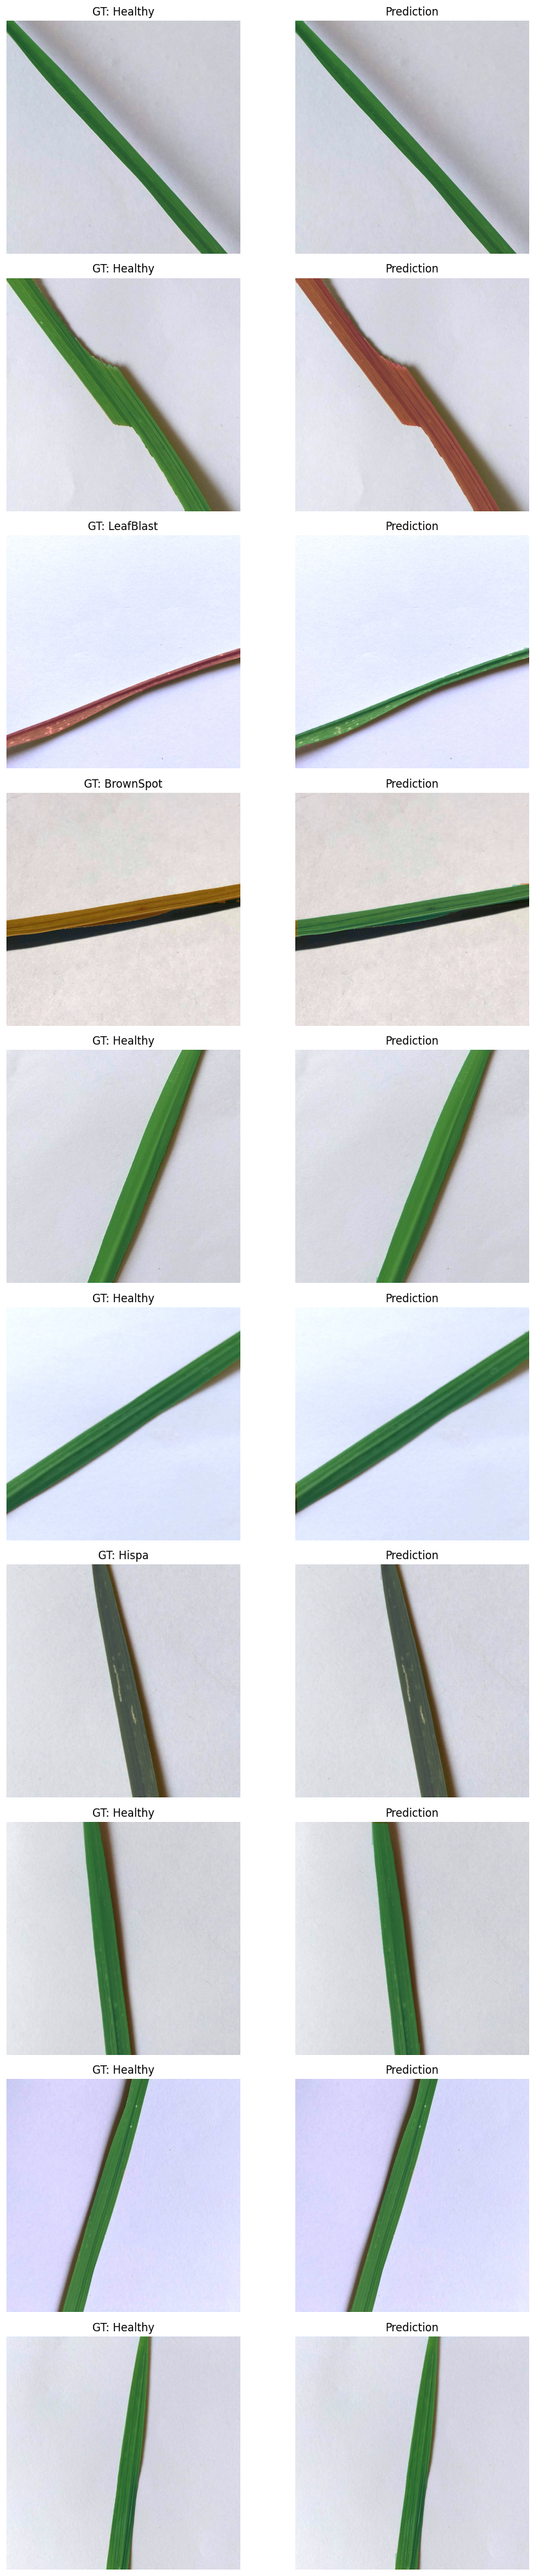

,sample_id,label,mIoU,Dice,gt_classes,pred_classes,pair_error
422,rice_0002152,Hispa,0.0,0.0,Hispa,Healthy,False
421,rice_0000053,BrownSpot,0.0,0.0,BrownSpot,Healthy,False
46,rice_0002561,Hispa,0.0,0.0,Hispa,Healthy,False
45,rice_0003006,LeafBlast,0.0,0.0,LeafBlast,Healthy,False
52,rice_0003209,LeafBlast,0.0,0.0,LeafBlast,BrownSpot,True
359,rice_0002612,Hispa,0.0,0.0,Hispa,,False
64,rice_0003228,LeafBlast,0.0,0.0,LeafBlast,Healthy,False
60,rice_0002155,Hispa,0.0,0.0,Hispa,Healthy,False
356,rice_0000009,BrownSpot,0.0,0.0,BrownSpot,LeafBlast,True
272,rice_0002167,Hispa,0.0,0.0,Hispa,Healthy,False


,sample_id,label,mIoU,Dice,gt_classes,pred_classes
30,rice_0000061,BrownSpot,0.000000,0.000000,BrownSpot,LeafBlast
52,rice_0003209,LeafBlast,0.000000,0.000000,LeafBlast,BrownSpot
83,rice_0003202,LeafBlast,0.000000,0.000000,LeafBlast,BrownSpot
194,rice_0003403,LeafBlast,0.000000,0.000000,LeafBlast,BrownSpot
356,rice_0000009,BrownSpot,0.000000,0.000000,BrownSpot,LeafBlast
397,rice_0003229,LeafBlast,0.000000,0.000000,LeafBlast,BrownSpot
417,rice_0003177,LeafBlast,0.000000,0.000000,LeafBlast,BrownSpot
275,rice_0000511,BrownSpot,0.103052,0.170884,BrownSpot,"BrownSpot,LeafBlast"
318,rice_0003224,LeafBlast,0.486451,0.493132,LeafBlast,"BrownSpot,LeafBlast"
312,rice_0003318,LeafBlast,0.488182,0.494020,LeafBlast,"BrownSpot,LeafBlast"


In [7]:
def rasterize_label_file(label_path: Path, width: int, height: int) -> np.ndarray:
    masks = np.zeros((len(CLASS_NAMES), height, width), dtype=bool)
    for class_id, coords in read_yolo_label(label_path):
        pixel_points = [(float(x) * width, float(y) * height) for x, y in coords]
        mask_img = Image.new("L", (width, height), 0)
        ImageDraw.Draw(mask_img).polygon(pixel_points, outline=1, fill=1)
        masks[class_id] |= np.asarray(mask_img, dtype=bool)
    return masks


def rasterize_predictions(result, width: int, height: int) -> np.ndarray:
    masks = np.zeros((len(CLASS_NAMES), height, width), dtype=bool)
    if result.masks is None or result.boxes is None or len(result.boxes) == 0:
        return masks
    pred_masks = result.masks.data.detach().cpu().numpy()
    pred_classes = result.boxes.cls.detach().cpu().numpy().astype(int)
    for class_id, mask in zip(pred_classes, pred_masks):
        if not 0 <= int(class_id) < len(CLASS_NAMES):
            continue
        mask_bool = mask > 0.5
        if mask_bool.shape != (height, width):
            mask_img = Image.fromarray((mask_bool.astype(np.uint8) * 255)).resize((width, height), Image.Resampling.NEAREST)
            mask_bool = np.asarray(mask_img, dtype=np.uint8) > 0
        masks[int(class_id)] |= mask_bool
    return masks


def mean_iou_dice(gt: np.ndarray, pred: np.ndarray) -> tuple[float, float, dict, list[str], list[str]]:
    ious = []
    dices = []
    per_class = {}
    gt_classes = []
    pred_classes = []
    for class_id, class_name in enumerate(CLASS_NAMES):
        gt_mask = gt[class_id]
        pred_mask = pred[class_id]
        if gt_mask.any():
            gt_classes.append(class_name)
        if pred_mask.any():
            pred_classes.append(class_name)
        if not gt_mask.any() and not pred_mask.any():
            continue
        intersection = np.logical_and(gt_mask, pred_mask).sum()
        union = np.logical_or(gt_mask, pred_mask).sum()
        denom = gt_mask.sum() + pred_mask.sum()
        iou = float(intersection / union) if union else 1.0
        dice = float(2 * intersection / denom) if denom else 1.0
        ious.append(iou)
        dices.append(dice)
        per_class[class_name] = {"iou": iou, "dice": dice}
    return float(np.mean(ious)) if ious else 0.0, float(np.mean(dices)) if dices else 0.0, per_class, gt_classes, pred_classes


CONFUSION_PAIRS = {frozenset(["BrownSpot", "LeafBlast"]), frozenset(["AlgalLeafSpot", "Rust"])}


def evaluate_custom_masks(ckpt: Path, df: pd.DataFrame, imgsz: int = 640, max_images: int | None = None) -> tuple[dict, pd.DataFrame]:
    model = YOLO(str(ckpt))
    test_df = df[df["split"] == "test"].copy()
    if max_images:
        test_df = test_df.sample(n=min(max_images, len(test_df)), random_state=SEED)
    rows = []
    for _, row in test_df.iterrows():
        image_path = Path(row["image_path_yolo"])
        image = Image.open(image_path).convert("RGB")
        width, height = image.size
        gt = rasterize_label_file(Path(row["label_path"]), width, height)
        result = model.predict(str(image_path), imgsz=imgsz, device=DEVICE, verbose=False)[0]
        pred = rasterize_predictions(result, width, height)
        miou, dice, per_class, gt_classes, pred_classes = mean_iou_dice(gt, pred)
        pair_error = any(pair <= set(gt_classes + pred_classes) for pair in CONFUSION_PAIRS)
        rows.append({
            "sample_id": row["sample_id"],
            "label": row["label"],
            "mIoU": miou,
            "Dice": dice,
            "gt_classes": ",".join(gt_classes),
            "pred_classes": ",".join(pred_classes),
            "pair_error": pair_error,
            "per_class": json.dumps(per_class),
        })
    score_df = pd.DataFrame(rows)
    summary = {
        "mIoU": float(score_df["mIoU"].mean()) if not score_df.empty else 0.0,
        "Dice": float(score_df["Dice"].mean()) if not score_df.empty else 0.0,
        "n_test_images": int(len(score_df)),
    }
    return summary, score_df


def benchmark_inference(ckpt: Path, df: pd.DataFrame, imgsz: int = 640, n_images: int = 50) -> float:
    model = YOLO(str(ckpt))
    test_paths = [Path(p) for p in df[df["split"] == "test"]["image_path_yolo"].head(n_images)]
    if not test_paths:
        return float("nan")
    for image_path in test_paths[:3]:
        model.predict(str(image_path), imgsz=imgsz, device=DEVICE, verbose=False)
    start = time.perf_counter()
    for image_path in test_paths:
        model.predict(str(image_path), imgsz=imgsz, device=DEVICE, verbose=False)
    return (time.perf_counter() - start) * 1000.0 / len(test_paths)


def draw_prediction_overlay(image_path: Path, result, alpha: int = 95) -> Image.Image:
    image = Image.open(image_path).convert("RGBA")
    width, height = image.size
    overlay = Image.new("RGBA", image.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    if result.masks is not None and result.boxes is not None:
        masks = result.masks.xy
        classes = result.boxes.cls.detach().cpu().numpy().astype(int)
        for class_id, xy in zip(classes, masks):
            if len(xy) < 3 or not 0 <= int(class_id) < len(PALETTE):
                continue
            rgb = tuple(int(PALETTE[int(class_id)].lstrip("#")[i:i+2], 16) for i in (0, 2, 4))
            draw.polygon([(float(x), float(y)) for x, y in xy], outline=rgb + (255,), fill=rgb + (alpha,))
    return Image.alpha_composite(image, overlay).convert("RGB")


def plot_prediction_samples(ckpt: Path, df: pd.DataFrame, n: int = 10) -> None:
    model = YOLO(str(ckpt))
    sample = df[df["split"] == "test"].sample(n=min(n, len(df[df["split"] == "test"])), random_state=SEED)
    fig, axes = plt.subplots(len(sample), 2, figsize=(10, 4 * len(sample)))
    if len(sample) == 1:
        axes = np.asarray([axes])
    for ax_row, (_, row) in zip(axes, sample.iterrows()):
        image_path = Path(row["image_path_yolo"])
        result = model.predict(str(image_path), imgsz=640, device=DEVICE, verbose=False)[0]
        ax_row[0].imshow(overlay_segments(image_path, Path(row["label_path"])))
        ax_row[0].set_title(f"GT: {row['label']}")
        ax_row[0].axis("off")
        ax_row[1].imshow(draw_prediction_overlay(image_path, result))
        ax_row[1].set_title("Prediction")
        ax_row[1].axis("off")
    plt.tight_layout()
    plt.show()


if metric_table.empty:
    env_ckpt = os.environ.get("BEST_CKPT", "")
    if not env_ckpt:
        raise RuntimeError("No trained run available. Set RUN_FULL_TRAINING=1 or BEST_CKPT=/path/to/best.pt.")
    best_ckpt = Path(env_ckpt)
    metric_table = pd.DataFrame([{"run": f"external_yolo26_seg_{TARGET_DOMAIN}", "best_ckpt": str(best_ckpt), "imgsz": 640}])
else:
    best_ckpt = Path(metric_table.iloc[0]["best_ckpt"])

print(f"Best checkpoint: {best_ckpt}")
CUSTOM_EVAL_MAX_IMAGES = int(os.environ.get("CUSTOM_EVAL_MAX_IMAGES", "0")) or None
custom_summary, custom_score_df = evaluate_custom_masks(best_ckpt, converted_df, imgsz=640, max_images=CUSTOM_EVAL_MAX_IMAGES)
speed_ms = benchmark_inference(best_ckpt, converted_df, imgsz=640, n_images=int(os.environ.get("BENCHMARK_IMAGES", "50")))
print(custom_summary)
print(f"Inference: {speed_ms:.2f} ms/image")

custom_score_df.to_csv(ARTIFACTS_DIR / f"phase3_yolo26_seg_{TARGET_DOMAIN}_custom_mask_scores.csv", index=False)
summary_rows = metric_table.copy()
summary_rows["dataset"] = TARGET_DOMAIN
summary_rows["mIoU"] = custom_summary["mIoU"]
summary_rows["Dice"] = custom_summary["Dice"]
summary_rows["inference_ms_img"] = speed_ms
summary_rows.to_csv(ARTIFACTS_DIR / f"phase3_yolo26_seg_{TARGET_DOMAIN}_summary.csv", index=False)
display(summary_rows)

plot_prediction_samples(best_ckpt, converted_df, n=10)

worst = custom_score_df.sort_values("mIoU").head(12)
display(worst[["sample_id", "label", "mIoU", "Dice", "gt_classes", "pred_classes", "pair_error"]])
pair_errors = custom_score_df[custom_score_df["pair_error"]].sort_values("mIoU").head(10)
display(pair_errors[["sample_id", "label", "mIoU", "Dice", "gt_classes", "pred_classes"]])


## 7. Save Phase 3 artifacts

In [8]:
shutil.copy2(best_ckpt, ARTIFACTS_DIR / f"best_yolo26_seg_{TARGET_DOMAIN}.pt")
shutil.copy2(DATA_YAML, ARTIFACTS_DIR / f"data_{TARGET_DOMAIN}.yaml")
(ARTIFACTS_DIR / "class_names.json").write_text(json.dumps(CLASS_NAMES, indent=2, ensure_ascii=False), encoding="utf-8")

model_card = f"""# YOLO26-seg Phase 3 - {TARGET_DOMAIN.title()} Leaf Disease Segmentation

Owner: Nguyen Ho Anh Tuan

## Task
Instance segmentation for Vietnamese {TARGET_DOMAIN} leaf disease images.

## Classes
{DOMAIN_CLASSES}

## Checkpoint
`{best_ckpt}`

## Metrics

- mask mAP@50: {summary_rows.iloc[0].get('mAP50_mask')}
- mask mAP@50:95: {summary_rows.iloc[0].get('mAP50_95_mask')}
- custom mIoU: {custom_summary['mIoU']:.6f}
- custom Dice: {custom_summary['Dice']:.6f}
- inference: {speed_ms:.2f} ms/image

See `phase3_yolo26_seg_{TARGET_DOMAIN}_summary.csv` and `phase3_yolo26_seg_{TARGET_DOMAIN}_custom_mask_scores.csv` for full results.
"""
(ARTIFACTS_DIR / "README.md").write_text(model_card, encoding="utf-8")
print(f"Artifacts written to {ARTIFACTS_DIR}")
print(sorted(p.name for p in ARTIFACTS_DIR.iterdir()))


Artifacts written to /kaggle/working/yolo26_seg_phase3_rice/artifacts
['README.md', 'best_yolo26_seg_rice.pt', 'class_names.json', 'conversion_skipped.csv', 'converted_manifest.csv', 'data_rice.yaml', 'phase3_yolo26_seg_rice_custom_mask_scores.csv', 'phase3_yolo26_seg_rice_summary.csv', 'phase3_yolo26_seg_rice_ultralytics_metrics.csv']


## 8. Optional HuggingFace Hub upload

Set `HF_REPO_ID`, `HF_TOKEN`, and `HF_UPLOAD=1` in Kaggle secrets/environment before running this cell.

In [9]:
HF_REPO_ID = os.environ.get("HF_REPO_ID", f"<team-or-user>/ml-vietnam-plant-disease-yolo26-seg-{TARGET_DOMAIN}")
HF_UPLOAD = os.environ.get("HF_UPLOAD", "0") == "1"

if HF_UPLOAD:
    from huggingface_hub import create_repo, upload_folder

    token = os.environ.get("HF_TOKEN")
    if not token:
        raise RuntimeError("Set HF_TOKEN before uploading to HuggingFace Hub.")
    if HF_REPO_ID.startswith("<team-or-user>"):
        raise RuntimeError("Set HF_REPO_ID to the real HuggingFace repo id before upload.")
    create_repo(repo_id=HF_REPO_ID, repo_type="model", private=False, exist_ok=True, token=token)
    upload_folder(
        repo_id=HF_REPO_ID,
        repo_type="model",
        folder_path=str(ARTIFACTS_DIR),
        commit_message=f"Add YOLO26-seg Phase 3 {TARGET_DOMAIN} artifacts",
        token=token,
    )
    print(f"Uploaded artifacts to https://huggingface.co/{HF_REPO_ID}")
else:
    print("HF_UPLOAD=0, skipping upload.")
    print(f"When ready, set HF_REPO_ID={HF_REPO_ID!r}, HF_TOKEN, and HF_UPLOAD=1.")


HF_UPLOAD=0, skipping upload.
When ready, set HF_REPO_ID='<team-or-user>/ml-vietnam-plant-disease-yolo26-seg-rice', HF_TOKEN, and HF_UPLOAD=1.
